In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("data.csv")

In [7]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 83 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1456 non-null   int64  
 1   MSZoning       1456 non-null   object 
 2   LotFrontage    1456 non-null   float64
 3   LotArea        1456 non-null   int64  
 4   Street         1456 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1456 non-null   object 
 7   LandContour    1456 non-null   object 
 8   Utilities      1456 non-null   object 
 9   LotConfig      1456 non-null   object 
 10  LandSlope      1456 non-null   object 
 11  Neighborhood   1456 non-null   object 
 12  Condition1     1456 non-null   object 
 13  Condition2     1456 non-null   object 
 14  BldgType       1456 non-null   object 
 15  HouseStyle     1456 non-null   object 
 16  OverallQual    1456 non-null   int64  
 17  OverallCond    1456 non-null   int64  
 18  YearBuil

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,HouseAge,TotalBath
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.00000,1456.000000,1456.000000,1456.000000,1456.000000,...,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,56.888736,69.570055,10448.784341,6.088599,5.576236,1971.18544,1984.819368,101.526786,436.991071,46.677198,...,3.418956,15.102335,2.055632,43.608516,6.326236,2007.817308,180151.233516,2551.300137,36.631868,2.204670
std,42.358363,20.903753,9860.763449,1.369669,1.113966,30.20159,20.652143,177.011773,430.255052,161.522376,...,29.357056,55.828405,35.383772,496.799265,2.698356,1.329394,76696.592530,758.353116,30.247555,0.778141
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.00000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,334.000000,0.000000,1.000000
25%,20.000000,60.000000,7538.750000,5.000000,5.000000,1954.00000,1966.750000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129900.000000,2008.000000,8.000000,2.000000
50%,50.000000,69.000000,9468.500000,6.000000,5.000000,1972.00000,1993.500000,0.000000,381.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,2472.000000,35.000000,2.000000
75%,70.000000,79.000000,11588.000000,7.000000,6.000000,2000.00000,2004.000000,163.250000,706.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,2999.250000,54.000000,2.500000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.00000,2010.000000,1600.000000,2188.000000,1474.000000,...,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,625000.000000,6428.000000,136.000000,6.000000


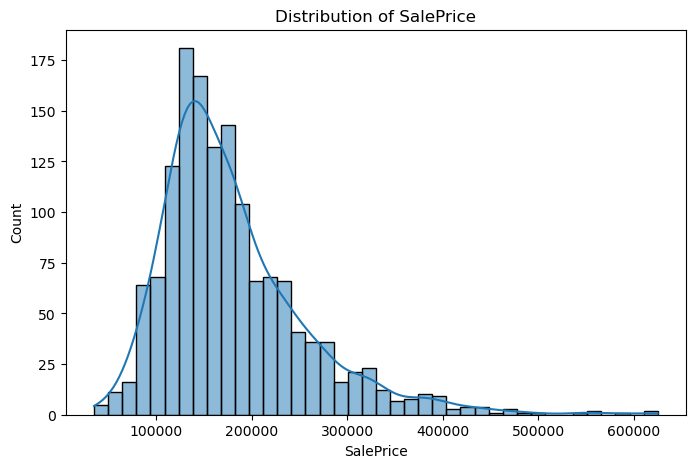

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

In [9]:
print("Skewness:", df['SalePrice'].skew())

Skewness: 1.5659592925562151


The SalePrice distribution is positively skewed with a long right tail.
Majority of houses are clustered between 200,000, while a few high-priced houses extend the distribution up to $700,000.
Since regression models perform better with normally distributed targets, log transformation will be applied to reduce skewness.

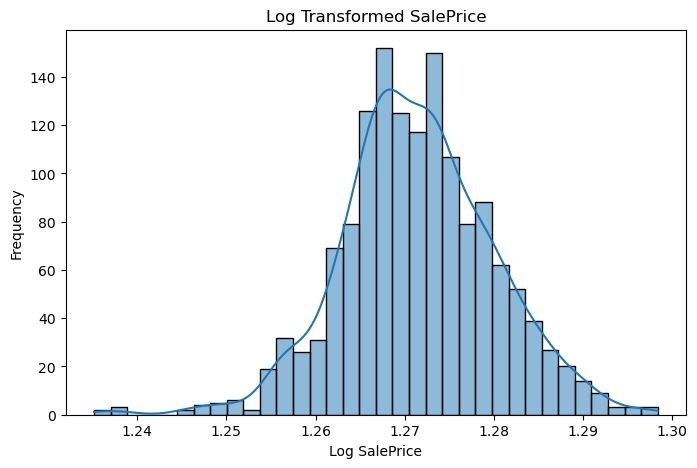

In [30]:
df['SalePrice'] = np.log1p(df['SalePrice'])
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Log Transformed SalePrice")
plt.xlabel("Log SalePrice")
plt.ylabel("Frequency")
plt.show()

In [31]:
print("Skewness after log:", df['SalePrice'].skew())

Skewness after log: -0.09457892624401458


The original SalePrice distribution was positively skewed with a long right tail due to high-priced houses.
Log transformation was applied using log1p() to reduce skewness.
After transformation, skewness reduced to approximately 0 (-0.009), indicating a nearly normal distribution.
This improves regression model stability and prediction performance.

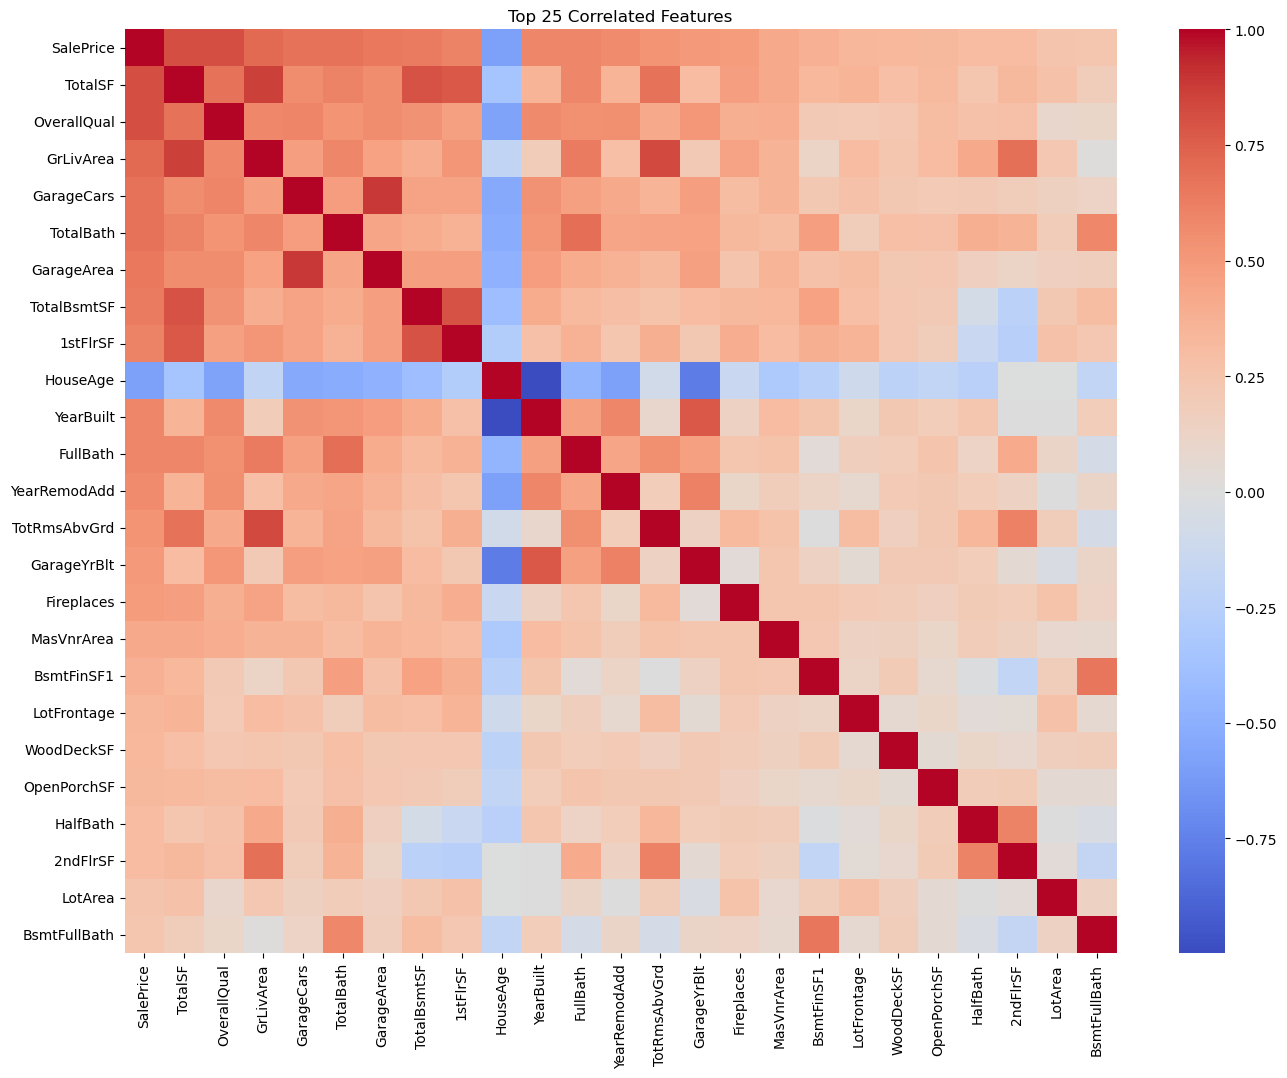

In [32]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr().abs()
top_features = corr['SalePrice'].sort_values(ascending=False).head(25).index
plt.figure(figsize=(16,12))
sns.heatmap(df[top_features].corr(), cmap='coolwarm', annot=False)
plt.title("Top 25 Correlated Features")
plt.show()

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

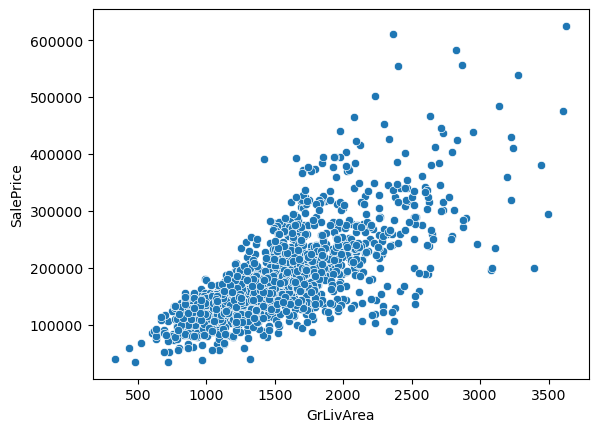

In [11]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

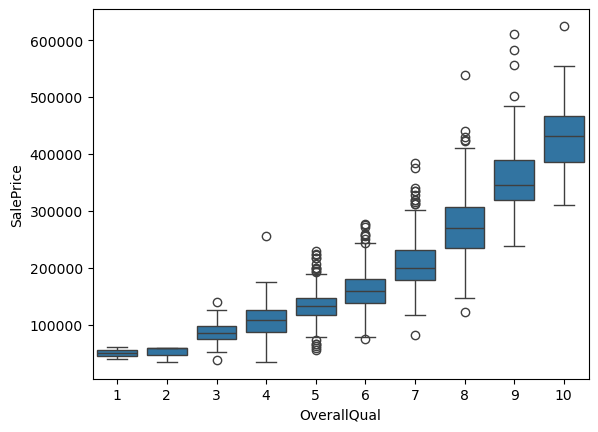

In [10]:
sns.boxplot(x='OverallQual', y='SalePrice', data=df)

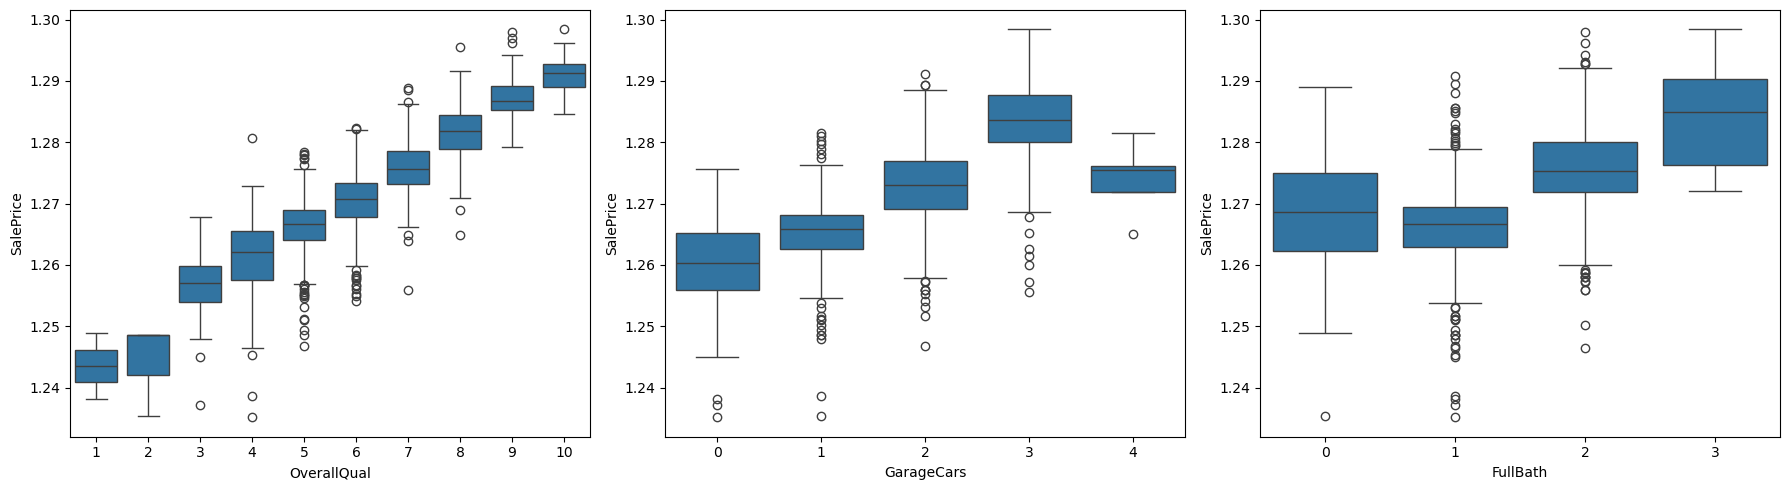

In [37]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.subplot(1,3,2)
sns.boxplot(x='GarageCars', y='SalePrice', data=df)
plt.subplot(1,3,3)
sns.boxplot(x='FullBath', y='SalePrice', data=df)
plt.tight_layout()
plt.show()

Task 1 Conclusion:
1.Houses with higher OverallQual have significantly higher prices.
2.GrLivArea strongly positively correlates with SalePrice.
3.GarageCars also increases house value.
4.SalePrice slightly right skewed

In [16]:
#Handling Missing Values
df.fillna(0, inplace=True)

In [38]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
#Define X and Y
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [39]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("R2:", r2_score(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

R2: 0.8933036884000027
RMSE: 0.12981314481799394


In [20]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("R2:", r2_score(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

R2: 0.8689152454156976
RMSE: 0.1438865039542366


In [21]:
#Gradient Boost
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
print("R2:", r2_score(y_test, pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_gb)))

R2: 0.8968266644858318
RMSE: 0.12765202349688082


In [40]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_gb))
    ]
})
results

,Model,R2 Score,RMSE
0,Linear Regression,0.893304,0.129813
1,Random Forest,0.868915,0.143887
2,Gradient Boosting,0.896827,0.127652


Gradient Boosting gives highest R2.
Random Forest handles non-linear relationships better.
Linear Regression performs lower due to complex feature interactions.

In [24]:
#Relationship Analysis
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

TotalSF         0.417408
OverallQual     0.345945
GarageArea      0.015759
GrLivArea       0.014696
GarageCars      0.011929
BsmtFinSF1      0.011899
TotalBath       0.011815
YearRemodAdd    0.010442
HouseAge        0.010032
LotArea         0.009385
dtype: float64

OverallQual increases price
GrLivArea increases price
GarageCars impacts price
Neighborhood affects price significantly

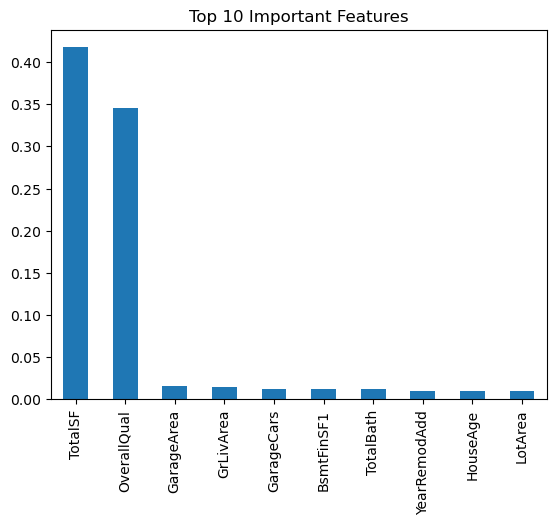

In [25]:
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

Suggestions for the customer to buy the house according to the area, price and other requirements:

1.Houses with OverallQual ≥ 7 give better resale value.
2.Larger living area (GrLivArea > 1500 sqft) increases value significantly.
3.Neighborhood plays a major role — premium areas cost more.
4.Garage capacity improves property value.
5.Recently remodeled homes (YearRemodAdd close to current year) are better investment